<a href="https://colab.research.google.com/github/positivefunctionIN/Medical_Imaging_using_CNN/blob/main/Model1_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from google.colab import files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Add, Multiply, Concatenate, Activation, Lambda
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_5b435f7615b49cc51191f5ab984c36d2"

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

data_path = "/content/chest_xray_data/chest_xray"

IMG_SIZE = 224
BATCH_SIZE = 32
CLASS_NAMES = ['Normal', 'Pneumonia']
NUM_CLASSES = 1

TensorFlow version: 2.20.0
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:22<00:00, 109MB/s]



In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)
val_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    f"{data_path}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n✅ Train samples: {train_generator.samples}")
print(f"✅ Val samples: {val_generator.samples}")
print(f"✅ Test samples: {test_generator.samples}")
print(f"✅ Class mapping: {train_generator.class_indices}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

✅ Train samples: 4173
✅ Val samples: 1043
✅ Test samples: 624
✅ Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}


In [3]:
print("\n" + "="*60)
print("🔵 MODEL 1: Custom CNN (From Scratch)")
print("="*60)

def build_custom_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='sigmoid')
    ])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Custom CNN built")
custom_cnn.summary()

custom_history = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

custom_test_loss, custom_test_acc = custom_cnn.evaluate(test_generator, verbose=0)
print(f"\n📊 Custom CNN Test Accuracy: {custom_test_acc:.2%}")


🔵 MODEL 1: Custom CNN (From Scratch)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Custom CNN built


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,263,809 (73.49 MB)

 Trainable params: 19,263,809 (73.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 120s 838ms/step - accuracy: 0.8196 - loss: 0.3981 - val_accuracy: 0.8562 - val_loss: 0.3003
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 133s 834ms/step - accuracy: 0.8953 - loss: 0.2538 - val_accuracy: 0.8869 - val_loss: 0.2569
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 799ms/step - accuracy: 0.9183 - loss: 0.2096 - val_accuracy: 0.9300 - val_loss: 0.1774
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 790ms/step - accuracy: 0.9178 - loss: 0.2063 - val_accuracy: 0.9185 - val_loss: 0.2006
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 786ms/step - accuracy: 0.9288 - loss: 0.1878 - val_accuracy: 0.8859 - val_loss: 0.2919
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 789ms/step - accuracy: 0.9339 - loss: 0.1737 - val_accuracy: 0.9291 - val_loss: 0.1662
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 784ms/step - accuracy: 0.9329 - loss: 0.1719 - val_accuracy: 0.9310 - val_loss: 0.1804
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 777ms/step - accuracy: 0.9384 -

**Adding Grad-Cam**

In [6]:
for i, layer in enumerate(custom_cnn.layers):
    print(i, layer.name)

0 conv2d
1 max_pooling2d
2 conv2d_1
3 max_pooling2d_1
4 conv2d_2
5 max_pooling2d_2
6 conv2d_3
7 max_pooling2d_3
8 flatten
9 dense
10 dropout
11 dense_1


In [7]:
dummy = np.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
_ = custom_cnn.predict(dummy, verbose=0)

In [8]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    last_conv_layer = model.get_layer(last_conv_layer_name)

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_layer.output, model.outputs[0]]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + tf.keras.backend.epsilon()

    return heatmap.numpy()

In [9]:
test_generator.reset()

images, labels = next(test_generator)

img = images[0]
label = labels[0]

img_array = np.expand_dims(img, axis=0)

pred = custom_cnn.predict(img_array, verbose=0)[0][0]

pred_class = "PNEUMONIA" if pred > 0.5 else "NORMAL"
actual_class = "PNEUMONIA" if label == 1 else "NORMAL"

print("Actual:", actual_class)
print("Predicted:", pred_class)
print("Confidence:", pred)

Actual: NORMAL
Predicted: PNEUMONIA
Confidence: 0.52726406


In [10]:
heatmap = make_gradcam_heatmap(
    img_array,
    custom_cnn,
    "conv2d_3"
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [11]:
heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

original = (img * 255).astype(np.uint8)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap,
    0.4,
    0
)

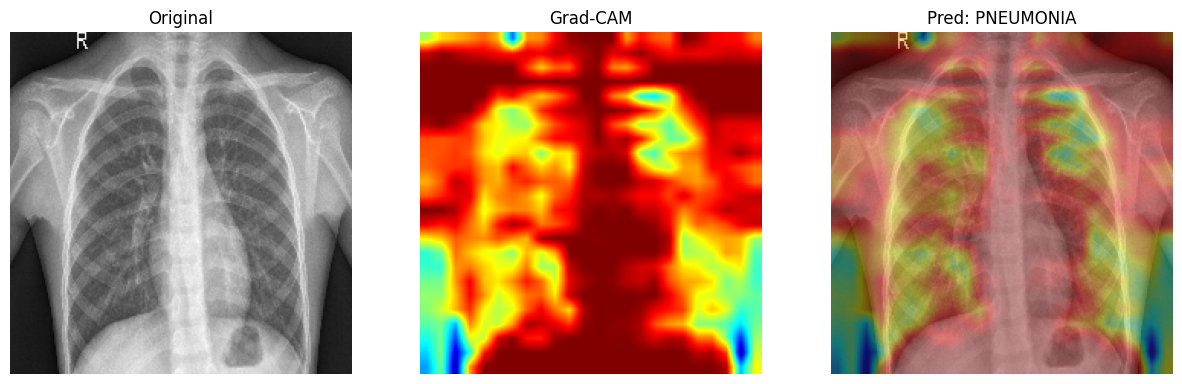

In [12]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Pred: {pred_class}")
plt.axis("off")

plt.show()